In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Segmentasi Citra


In [ ]:
def order_points(pts: np.ndarray) -> np.ndarray:
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

def find_card_corners(image: np.ndarray):
    total_area = image.shape[0] * image.shape[1]

    # 1. Grayscale & Blur
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # 2. Canny Edge (Sensitivitas diubah agar retakan meja yang halus diabaikan)
    edged = cv2.Canny(blurred, 70, 200)

    # 3. Morfologi Tipis (Dilasi dengan kernel 3x3, 1 iterasi saja)
    # Agar garis kartu nyambung, tapi "ekor" retakan tidak ikut bengkak
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    dilated = cv2.dilate(edged, kernel, iterations=1)

    # 4. Pencarian Kontur
    contours, _ = cv2.findContours(dilated.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]

    card_contour = None

    for c in contours:
        area = cv2.contourArea(c)
        # Abaikan objek kecil
        if area > (0.10 * total_area):
            perimeter = cv2.arcLength(c, True)

            # Dynamic Epsilon (Toleransi Dinamis)
            # Komputer mencoba berbagai tingkat toleransi dari 2% sampai 10%
            for eps in [0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.1]:
                approx = cv2.approxPolyDP(c, eps * perimeter, True)

                # Jika di toleransi tertentu ketemu tepat 4 sudut, kunci dan berhenti!
                if len(approx) == 4:
                    card_contour = approx
                    break

        # Jika kartu sudah ketemu, berhenti mengecek objek lain
        if card_contour is not None:
            break

    if card_contour is None:
        return None, dilated

    pts = card_contour.reshape(4, 2)
    return order_points(pts), dilated

print("Segmentasi Citra siap.")

Segmentasi Citra siap.


Menganalisis gambar dan mencari garis tepi...
STATUS: BERHASIL! 4 Titik sudut kartu ditemukan.


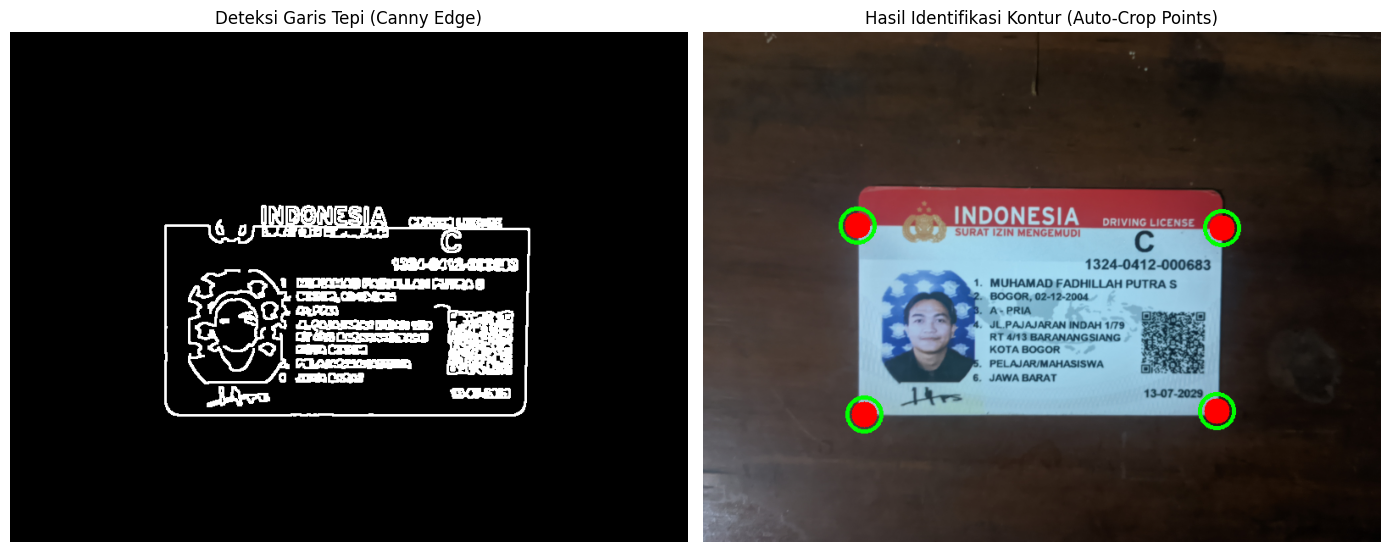

In [ ]:
# Uji coba segmentasi citra

nama_file = 'test_sim3.jpeg'
img_asli = cv2.imread(nama_file)

if img_asli is not None:
    # 1. Resize gambar agar komputasi lebih stabil
    lebar_baru = 800
    rasio = lebar_baru / img_asli.shape[1]
    dimensi_baru = (lebar_baru, int(img_asli.shape[0] * rasio))
    img_resized = cv2.resize(img_asli, dimensi_baru, interpolation=cv2.INTER_AREA)

    # Copy gambar untuk digambar titiknya (agar gambar asli tidak rusak)
    img_visualisasi = img_resized.copy()

    # 2. Eksekusi fungsi Segmentasi Citra
    print("Menganalisis gambar dan mencari garis tepi...")
    auto_corners, edge_map = find_card_corners(img_resized)

    # 3. Visualisasi Hasil
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Panel Kiri: Tampilan Canny Edge (Hitam Putih)
    axes[0].imshow(edge_map, cmap='gray')
    axes[0].set_title("Deteksi Garis Tepi (Canny Edge)")
    axes[0].axis('off')

    if auto_corners is not None:
        print("STATUS: BERHASIL! 4 Titik sudut kartu ditemukan.")

        # Gambar lingkaran merah besar di 4 sudut yang ditemukan komputer
        for point in auto_corners:
            x, y = int(point[0]), int(point[1])
            cv2.circle(img_visualisasi, (x, y), 15, (0, 0, 255), -1) # Titik merah
            cv2.circle(img_visualisasi, (x, y), 20, (0, 255, 0), 3)  # Lingkaran hijau luar

        # Konversi BGR ke RGB untuk Matplotlib
        img_rgb = cv2.cvtColor(img_visualisasi, cv2.COLOR_BGR2RGB)

        # Panel Kanan: Gambar Asli dengan Titik Pelacakan
        axes[1].imshow(img_rgb)
        axes[1].set_title("Hasil Identifikasi Kontur (Auto-Crop Points)")
        axes[1].axis('off')

    else:
        print("STATUS: GAGAL. Komputer tidak menemukan objek bersudut 4.")
        axes[1].text(0.5, 0.5, 'KARTU TIDAK TERDETEKSI', horizontalalignment='center', verticalalignment='center', fontsize=15)
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()

else:
    print(f"ERROR: Gambar '{nama_file}' tidak ditemukan.")

## Operasi Geometri

In [ ]:
def apply_geometry_warp(image: np.ndarray, corners: np.ndarray, width: int = 856, height: int = 540) -> np.ndarray:
    """
    Melakukan transformasi perspektif untuk merekonstruksi bentuk citra.
    Parameter:
    - image: Matriks citra asli (BGR)
    - corners: Array koordinat 4 sudut (Kiri-Atas, Kanan-Atas, Kanan-Bawah, Kiri-Bawah)
    """
    # Pastikan tipe data adalah float32 untuk presisi kalkulasi matriks OpenCV
    pts1 = np.float32(corners)

    # Deklarasi 4 titik tujuan (koordinat persegi panjang sempurna)
    pts2 = np.float32([
        [0, 0],               # Kiri Atas
        [width, 0],           # Kanan Atas
        [width, height],      # Kanan Bawah
        [0, height]           # Kiri Bawah
    ])

    # 1. Menghitung Matriks Homografi
    matrix = cv2.getPerspectiveTransform(pts1, pts2)

    # 2. Mengeksekusi Transformasi Piksel
    warped_image = cv2.warpPerspective(image, matrix, (width, height))

    return warped_image

print("Operasi Geomteri siap.")

Operasi Geomteri siap.


Mengeksekusi Tahap 1: Mencari koordinat...
Koordinat ditemukan. Mengeksekusi Tahap 2...


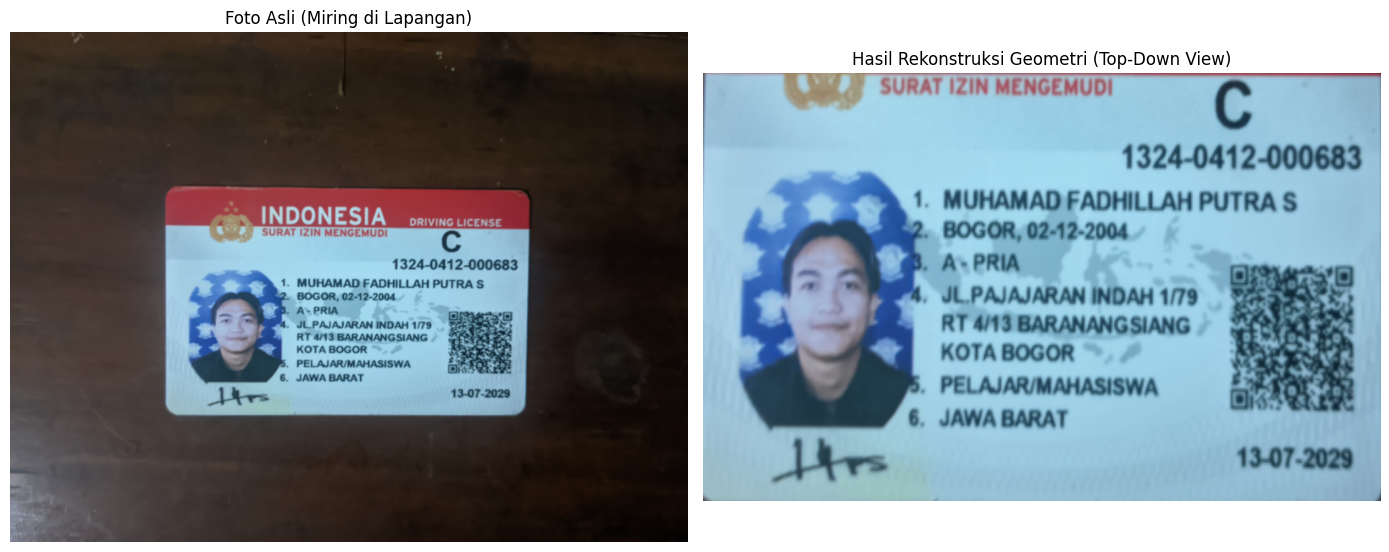

In [ ]:
# EKSEKUSI INTEGRASI (SEGMENTASI -> GEOMETRI)

import matplotlib.pyplot as plt

nama_file = 'test_sim3.jpeg' # Gunakan foto SIM yang berhasil dideteksi tadi
img_asli = cv2.imread(nama_file)

if img_asli is not None:
    # 1. Standardisasi Ukuran (Sama seperti Tahap 1)
    lebar_baru = 800
    rasio = lebar_baru / img_asli.shape[1]
    dimensi_baru = (lebar_baru, int(img_asli.shape[0] * rasio))
    img_resized = cv2.resize(img_asli, dimensi_baru, interpolation=cv2.INTER_AREA)

    # 2. TAHAP 1: Cari Koordinat
    print("Mengeksekusi Tahap 1: Mencari koordinat...")
    auto_corners, _ = find_card_corners(img_resized)

    if auto_corners is not None:
        print("Koordinat ditemukan. Mengeksekusi Tahap 2...")

        # 3. TAHAP 2: Lakukan Warping menggunakan koordinat dari Tahap 1
        hasil_warp = apply_geometry_warp(img_resized, auto_corners)

        # 4. Visualisasi Hasil
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Panel Kiri: Gambar Asli (RGB)
        axes[0].imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Foto Asli (Miring di Lapangan)")
        axes[0].axis('off')

        # Panel Kanan: Hasil Warp (RGB)
        axes[1].imshow(cv2.cvtColor(hasil_warp, cv2.COLOR_BGR2RGB))
        axes[1].set_title("Hasil Rekonstruksi Geometri (Top-Down View)")
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("GAGAL: Kartu tidak terdeteksi. Evaluasi kembali Tahap 1.")
else:
    print(f"ERROR: Gambar '{nama_file}' tidak ditemukan.")

## Operasi Filter

In [ ]:
def apply_median_filter(image: np.ndarray, kernel_size: int = 5) -> np.ndarray:
    """
    Menerapkan Median Filter untuk menghilangkan noise bintik (salt-and-pepper).
    Parameter:
    - image: Citra hasil warping (Tahap 2)
    - kernel_size: Ukuran jendela filter (harus bilangan ganjil, misal: 3, 5, atau 7)
    """
    # OpenCV mensyaratkan kernel_size harus ganjil
    if kernel_size % 2 == 0:
        kernel_size += 1

    # Eksekusi Median Blur
    filtered_image = cv2.medianBlur(image, kernel_size)

    return filtered_image

print("Cell 5 Dieksekusi: Fungsi apply_median_filter siap.")

Cell 5 Dieksekusi: Fungsi apply_median_filter siap.


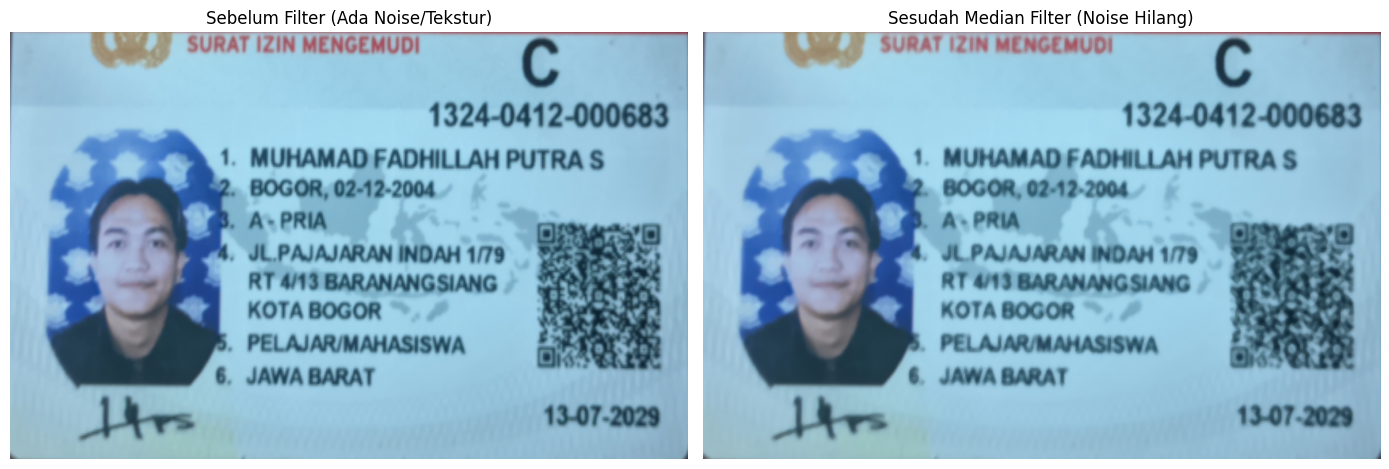

Evaluasi: Perhatikan permukaan kartu. Apakah tekstur bintik-bintik halus sudah tampak lebih rata?


In [ ]:
if 'hasil_warp' in locals():
    # 1. Eksekusi Filter
    hasil_filter = apply_median_filter(hasil_warp, kernel_size=5)

    # 2. Visualisasi Perbandingan
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Bandingkan area teks agar terlihat efek pembersihannya
    # Kita ambil potongan koordinat tengah agar teks terlihat jelas
    axes[0].imshow(cv2.cvtColor(hasil_warp, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Sebelum Filter (Ada Noise/Tekstur)")
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(hasil_filter, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Sesudah Median Filter (Noise Hilang)")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    print("Evaluasi: Perhatikan permukaan kartu. Apakah tekstur bintik-bintik halus sudah tampak lebih rata?")
else:
    print("ERROR: Jalankan Cell 4 terlebih dahulu untuk mendapatkan 'hasil_warp'.")

## terakhir / thresholding

In [ ]:
def apply_binarization(image: np.ndarray, block_size: int = 11, C: int = 2) -> np.ndarray:
    """
    Mengubah citra menjadi biner (hitam-putih) untuk ekstraksi teks.
    Parameter:
    - image: Citra hasil filter (Tahap 3)
    - block_size: Ukuran area lokal (harus bilangan ganjil, misal: 11)
    - C: Konstanta pengurang dari nilai rata-rata (untuk fine-tuning)
    """
    # 1. Konversi ke Grayscale (Wajib sebelum thresholding)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 2. Eksekusi Adaptive Thresholding
    binary_image = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        block_size,
        C
    )

    return binary_image

print("Cell 7 Dieksekusi: Fungsi apply_binarization siap.")

Cell 7 Dieksekusi: Fungsi apply_binarization siap.


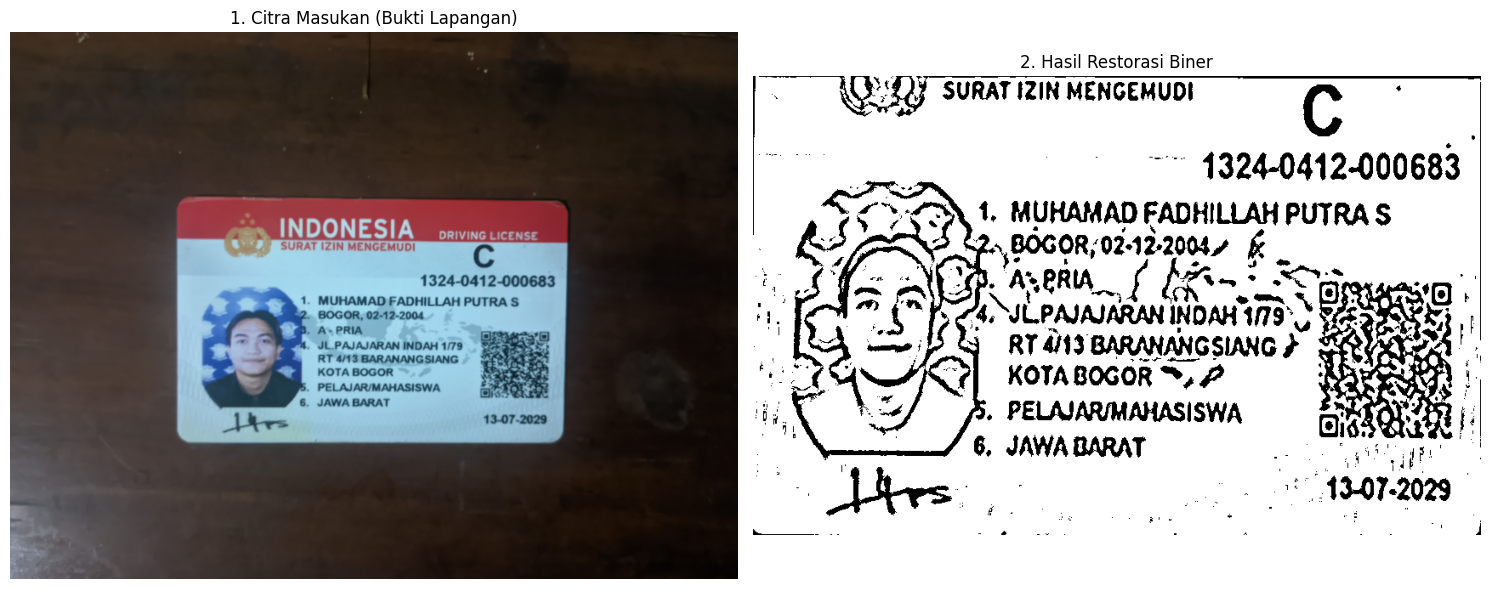

PROSES SELESAI: Hasil akhir telah disimpan sebagai 'hasil_restorasi.png'


In [ ]:
if 'hasil_filter' in locals():
    # 1. Eksekusi Binerisasi
    # Kita gunakan block_size 11 dan C 2 (standar dokumen)
    hasil_akhir = apply_binarization(hasil_filter, block_size=11, C=2)

    # 2. Visualisasi Final (Sesuai Poin 4 Ketentuan Tugas)
    fig, axes = plt.subplots(1, 2, figsize=(15, 8))

    # Gambar Asli
    axes[0].imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
    axes[0].set_title("1. Citra Masukan (Bukti Lapangan)")
    axes[0].axis('off')

    # Hasil Akhir Biner
    axes[1].imshow(hasil_akhir, cmap='gray')
    axes[1].set_title("2. Hasil Restorasi Biner")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    # 3. Simpan Hasil untuk Pengumpulan
    cv2.imwrite('hasil_restorasi.png', hasil_akhir)
    print("PROSES SELESAI: Hasil akhir telah disimpan sebagai 'hasil_restorasi.png'")

else:
    print("ERROR: Jalankan Cell 6 terlebih dahulu.")